In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('ecommerce_sales_beginner.csv')
df

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
0,1001,2025-06-29,Shoes,Fashion,1,3500.0,Mumbai,Cash
1,1002,2025-01-21,Mouse,Accessories,3,900.0,Delhi,Debit Card
2,1003,2025-03-16,Shoes,Fashion,3,3500.0,Pune,Cash
3,1004,2025-06-01,Backpack,Fashion,3,2200.0,Pune,Credit Card
4,1005,2025-06-07,Backpack,Fashion,2,2200.0,Delhi,Cash
...,...,...,...,...,...,...,...,...
147,1148,2025-05-16,Headphones,Electronics,4,2500.0,Pune,UPI
148,1149,2025-05-25,Monitor,Electronics,3,12000.0,Indore,UPI
149,1150,2025-02-05,Keyboard,Accessories,2,1800.0,Bengaluru,Debit Card
150,1011,2025-05-15,Headphones,Electronics,1,2500.0,Indore,Debit Card


In [7]:
df.head()

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
0,1001,2025-06-29,Shoes,Fashion,1,3500.0,Mumbai,Cash
1,1002,2025-01-21,Mouse,Accessories,3,900.0,Delhi,Debit Card
2,1003,2025-03-16,Shoes,Fashion,3,3500.0,Pune,Cash
3,1004,2025-06-01,Backpack,Fashion,3,2200.0,Pune,Credit Card
4,1005,2025-06-07,Backpack,Fashion,2,2200.0,Delhi,Cash


In [10]:
df.shape

(152, 8)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        152 non-null    int64  
 1   Order_Date      152 non-null    str    
 2   Product         152 non-null    str    
 3   Category        152 non-null    str    
 4   Quantity        152 non-null    int64  
 5   Price           151 non-null    float64
 6   City            151 non-null    str    
 7   Payment_Method  151 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 15.5 KB


In [13]:
df.describe()

,Order_ID,Quantity,Price
count,152.000000,152.000000,151.000000
mean,1074.947368,2.493421,11138.410596
std,43.500139,1.103857,17293.724723
min,1001.000000,1.000000,900.000000
25%,1037.750000,2.000000,1800.000000
50%,1074.500000,2.500000,2500.000000
75%,1112.250000,3.000000,12000.000000
max,1150.000000,4.000000,55000.000000


In [14]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             1
City              1
Payment_Method    1
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(2)

In [17]:
df[df.duplicated()]

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
150,1011,2025-05-15,Headphones,Electronics,1,2500.0,Indore,Debit Card
151,1056,2025-05-27,Shoes,Fashion,4,3500.0,Bengaluru,UPI


In [18]:
df =df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(150, 8)

In [25]:
df[df['Price'].isnull()]

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
40,1041,2025-01-27,Laptop,Electronics,2,NaN,Indore,Cash


In [26]:
df[df['City'].isnull()]

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
7,1008,2025-06-19,Shoes,Fashion,4,3500.0,NaN,Cash


In [27]:
df[df['Payment_Method'].isnull()]

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
25,1026,2025-06-12,Backpack,Fashion,3,2200.0,Indore,NaN


In [28]:
df['Order_Date'].dtype

<StringDtype(na_value=nan)>

In [30]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [31]:
df['Order_Date'].dtype

dtype('<M8[us]')

In [32]:
df[df['Product']=='Laptop']

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method
15,1016,2025-06-13,Laptop,Electronics,2,55000.0,Bengaluru,Credit Card
23,1024,2025-03-29,Laptop,Electronics,1,55000.0,Bengaluru,Cash
29,1030,2025-04-11,Laptop,Electronics,3,55000.0,Mumbai,UPI
40,1041,2025-01-27,Laptop,Electronics,2,NaN,Indore,Cash
45,1046,2025-03-03,Laptop,Electronics,1,55000.0,Delhi,Cash
48,1049,2025-01-02,Laptop,Electronics,2,55000.0,Bengaluru,Credit Card
56,1057,2025-06-17,Laptop,Electronics,4,55000.0,Delhi,Cash
57,1058,2025-01-11,Laptop,Electronics,4,55000.0,Indore,UPI
69,1070,2025-05-22,Laptop,Electronics,1,55000.0,Bengaluru,Cash
80,1081,2025-04-26,Laptop,Electronics,3,55000.0,Pune,UPI


In [33]:
laptop_price  = df.loc[df['Product']=='Laptop','Price'].median()
df['Price'] = df['Price'].fillna(laptop_price)

In [34]:
df['Price'].isnull().sum()

np.int64(0)

In [35]:
df['City'] = df['City'].fillna('Unknown')

In [36]:
df['City'].isnull().sum()

np.int64(0)

In [37]:
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

In [38]:
df['Payment_Method'].isnull().sum()

np.int64(0)

In [39]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
City              0
Payment_Method    0
dtype: int64

In [40]:
df['Sales'] =df['Quantity']*df['Price']

In [41]:
df.head()

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method,Sales
0,1001,2025-06-29,Shoes,Fashion,1,3500.0,Mumbai,Cash,3500.0
1,1002,2025-01-21,Mouse,Accessories,3,900.0,Delhi,Debit Card,2700.0
2,1003,2025-03-16,Shoes,Fashion,3,3500.0,Pune,Cash,10500.0
3,1004,2025-06-01,Backpack,Fashion,3,2200.0,Pune,Credit Card,6600.0
4,1005,2025-06-07,Backpack,Fashion,2,2200.0,Delhi,Cash,4400.0


## EDA (Exploratory Data Analysis)

## Question -1: Total Sales Kitni hui?

In [42]:
Total_Sales = df['Sales'].sum()
Total_Sales

np.float64(3907000.0)

## Question -2 Average Order Value 

In [43]:
# ek order per average customer kitna spend karta hai
Avg_Order =df['Sales'].mean()
Avg_Order


np.float64(26046.666666666668)

## Question -3 Total Quantity Sold

In [44]:
#kitne product total sell hue ?
total_product_sell =df['Quantity'].sum()
total_product_sell

np.int64(374)

## Question -4 Kaunsi Category Sabse Zyada Sales generate Karti hai ?

In [46]:
# here we use groupby() function
df.groupby('Category')["Sales"].sum()

Category
Accessories     154800.0
Electronics    3399500.0
Fashion         352700.0
Name: Sales, dtype: float64

In [47]:
df.groupby('Category')["Sales"].sum().sort_values(ascending = False)

Category
Electronics    3399500.0
Fashion         352700.0
Accessories     154800.0
Name: Sales, dtype: float64

##  Question -5 Top Products

In [51]:
#konse Product sabse jyada revenue generate kar rahe hai
df.groupby('Product')["Sales"].sum().sort_values(ascending = False)

Product
Laptop        2255000.0
Phone          570000.0
Monitor        492000.0
Shoes          185500.0
Backpack       167200.0
Keyboard       109800.0
Headphones      82500.0
Mouse           45000.0
Name: Sales, dtype: float64

## Question -6 Which City generates the most Sales 

In [49]:
df.groupby('City')["Sales"].sum().sort_values(ascending = False)

City
Indore       1115300.0
Pune          798000.0
Bengaluru     764800.0
Delhi         739800.0
Mumbai        475100.0
Unknown        14000.0
Name: Sales, dtype: float64

## Question - 7 Payment Method 

In [50]:
# kitni sales kis payment method se hue hai ?
df.groupby('Payment_Method')["Sales"].sum()

Payment_Method
Cash           1151300.0
Credit Card     911900.0
Debit Card      759700.0
UPI            1077500.0
Unknown           6600.0
Name: Sales, dtype: float64

In [52]:
df.groupby('Product')["Quantity"].sum().sort_values(ascending = False)

Product
Backpack      76
Keyboard      61
Shoes         53
Mouse         50
Monitor       41
Laptop        41
Headphones    33
Phone         19
Name: Quantity, dtype: int64

## Time Analysis

In [53]:
# question - Kis month me sabse zyada sales hue hai 
df['Month'] =df['Order_Date'].dt.to_period('M')

In [54]:
df.head()

,Order_ID,Order_Date,Product,Category,Quantity,Price,City,Payment_Method,Sales,Month
0,1001,2025-06-29,Shoes,Fashion,1,3500.0,Mumbai,Cash,3500.0,2025-06
1,1002,2025-01-21,Mouse,Accessories,3,900.0,Delhi,Debit Card,2700.0,2025-01
2,1003,2025-03-16,Shoes,Fashion,3,3500.0,Pune,Cash,10500.0,2025-03
3,1004,2025-06-01,Backpack,Fashion,3,2200.0,Pune,Credit Card,6600.0,2025-06
4,1005,2025-06-07,Backpack,Fashion,2,2200.0,Delhi,Cash,4400.0,2025-06


In [55]:
df.groupby('Month')["Sales"].sum().sort_values(ascending = False)

Month
2025-01    1155700.0
2025-05    1040500.0
2025-04     685500.0
2025-06     549300.0
2025-03     261400.0
2025-02     214600.0
Freq: M, Name: Sales, dtype: float64

##  Monthly Sales Trend 

## Sales Time ke sath kaise change ho rahi hai
monthly_sales = df.groupby('Month')["Sales"].sum()
plt.figure(figsize =(10,5))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker = 'o')

plt.title('Monthly Sales Trend')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.show()

##  Category Sales ka Bar Chart

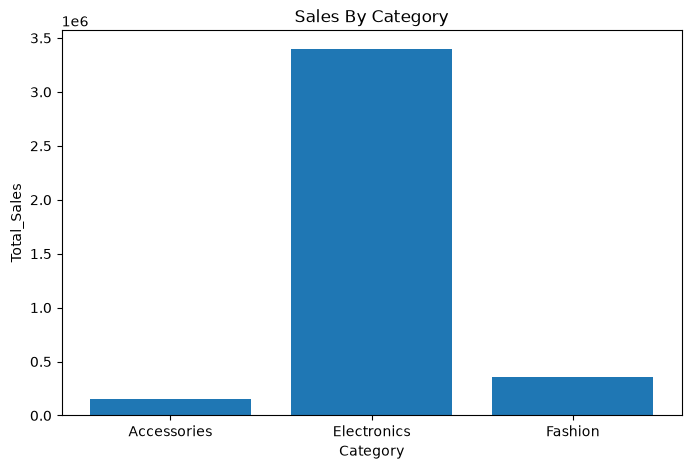

In [75]:
category_sales = df.groupby('Category')["Sales"].sum()
plt.figure(figsize =(8,5))

plt.bar(category_sales.index,category_sales.values)
plt.title('Sales By Category')
plt.xlabel('Category')
plt.ylabel('Total_Sales')

plt.show()

## Product Sales

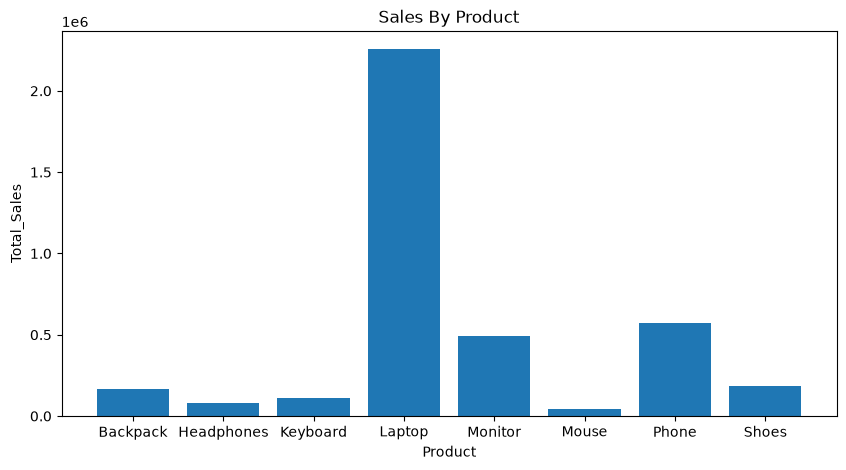

In [66]:
product_sales = df.groupby('Product')["Sales"].sum()
plt.figure(figsize =(10,5))
plt.bar(product_sales.index,product_sales.values)

plt.title('Sales By Product')
plt.xlabel('Product')
plt.ylabel('Total_Sales')

plt.show()

##  Use Seaborn Library

Text(0.5, 1.0, 'Orders By Payment Method')

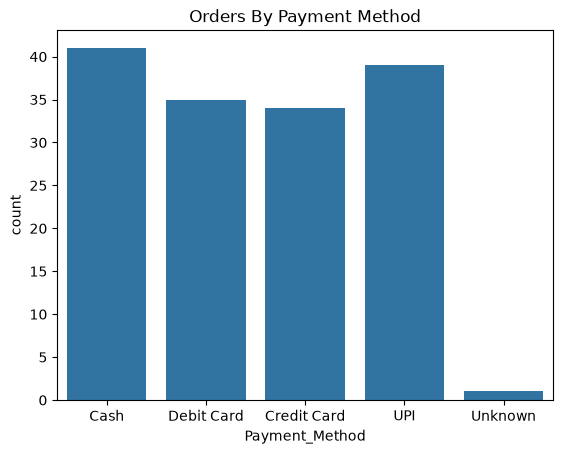

In [70]:
# Konsa payment method ka kitna usage hai

sns.countplot(data =df ,x= 'Payment_Method')
plt.title('Orders By Payment Method')


##  Sales Distribution

<Axes: xlabel='Sales', ylabel='Count'>

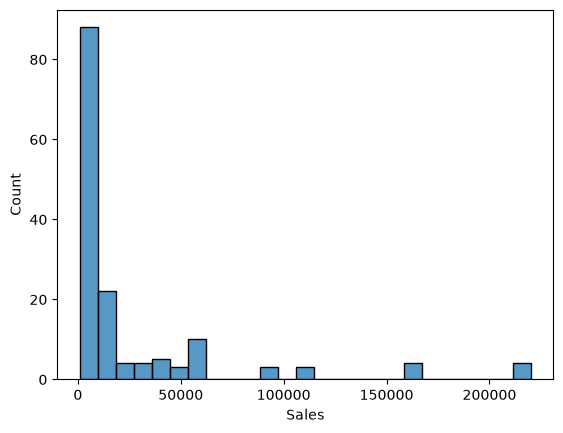

In [72]:
sns.histplot(data =df ,x ='Sales')

<Axes: ylabel='Sales'>

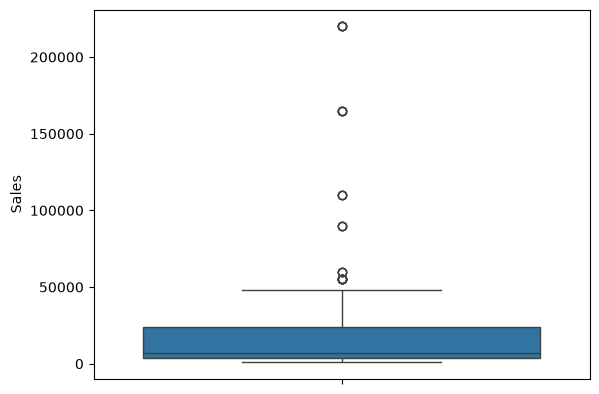

In [74]:
# Kya dataset mein unusually  high/low Sales Values hain?
#Boxplot
sns.boxplot(data =df ,y ='Sales')

##  Key Insights

1. Total sales were ₹39.07 lakh.
2. Electronics generated the highest revenue among categories.
3. Laptop generated the highest product-level revenue.
4. Backpack had the highest quantity sold.
5. Indore generated the highest sales among cities.
6. January had the highest monthly sales in this dataset.
7. Sales distribution is right-skewed, with some high-value orders.

## Conclusion

The analysis shows that Electronics is the major revenue-generating
category, while Laptop contributes the highest product-level revenue.
Although Backpack has the highest number of units sold, its revenue is
much lower because of its lower price.

Sales vary considerably across months and cities. The business could
further investigate high-value products, monthly sales fluctuations,
and city-level performance.